# Reentrenamiento con la variable de negatividad

Creamos una variable que mide qué tan negativo es cada tweet, la incorporamos al conjunto de
datos y volvemos a entrenar el clasificador del inciso 6 para responder si mejora el
desempeño y en qué medida.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score

from src.modelos import (
    build_model_columnas, compare_over_splits, evaluate_model, report,
    plot_confusion, TEST_SIZE, RANDOM_STATE, BEST_PARAMS,
)

sns.set_theme(style='whitegrid')

clean = pd.read_csv('../data/cleaned/train_cleaned.csv')
sent = pd.read_csv('../data/cleaned/train_sentimiento.csv')
assert (clean['id'] == sent['id']).all(), 'los archivos no están alineados'

print(f'{len(clean)} tweets')

7613 tweets


## 1. La variable de negatividad

Se define como el `compound` de VADER con el signo invertido:

$$\text{negatividad} = -\text{compound}$$

Queda acotada a [-1, 1], donde 1 es máxima negatividad y -1 máxima positividad. Se invierte
el signo solo para que la variable se lea en la dirección que nombra.

Dos precisiones sobre cómo se calcula:

- Proviene del **texto crudo**, por lo establecido en el inciso 8: la limpieza elimina 20 de
  las 59 negaciones que VADER reconoce e invierte el signo del resultado en el 11.26% de los
  tweets.
- Se calcula **tweet por tweet contra un léxico fijo**, sin ajustar nada a partir del
  conjunto de datos. No hay riesgo de fuga de información entre entrenamiento y prueba,
  porque el valor de un tweet no depende de los demás.

In [2]:
datos = pd.DataFrame({
    'text': clean['text'].fillna(''),
    'negatividad': sent['negatividad'],
    'n_positivas': sent['n_positivas'],
    'n_negativas': sent['n_negativas'],
})
y = clean['target']

display(datos.head())
print(datos[['negatividad', 'n_positivas', 'n_negativas']].describe().round(3))

,text,negatividad,n_positivas,n_negativas
0,deeds reason earthquake may allah forgive us,-0.2732,1,0
1,forest fire near la ronge sask canada,0.3400,0,1
2,residents asked shelter place notified officer...,0.2960,0,1
3,people receive wildfires evacuation orders cal...,-0.0000,0,0
4,got sent photo ruby alaska smoke wildfires pou...,-0.0000,0,0


       negatividad  n_positivas  n_negativas
count     7613.000     7613.000     7613.000
mean         0.149        0.568        0.948
std          0.457        0.857        1.009
min         -0.973        0.000        0.000
25%         -0.026        0.000        0.000
50%          0.000        0.000        1.000
75%          0.542        1.000        1.000
max          0.988        9.000       13.000


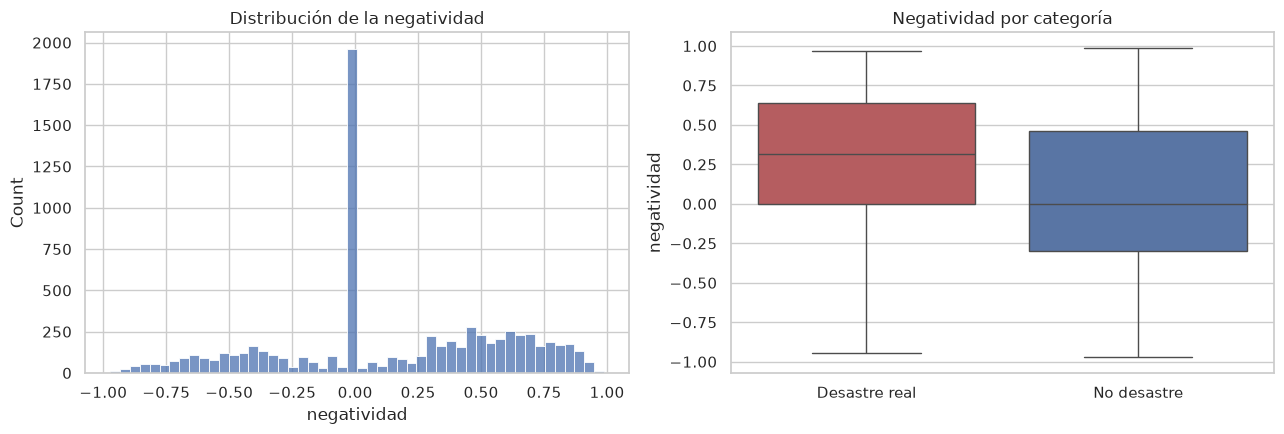

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(datos['negatividad'], bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de la negatividad')
axes[0].set_xlabel('negatividad')

tmp = datos.assign(categoria=y.map({0: 'No desastre', 1: 'Desastre real'}))
sns.boxplot(data=tmp, x='categoria', y='negatividad', hue='categoria',
            palette={'No desastre': '#4C72B0', 'Desastre real': '#C44E52'},
            legend=False, ax=axes[1])
axes[1].set_title('Negatividad por categoría')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 2. Montaje del experimento

El modelo del inciso 6 recibía una serie de texto. Para añadir una columna numérica hay que
reexpresarlo sobre un DataFrame con un `ColumnTransformer`: TF-IDF sobre la columna de texto
y estandarización sobre las numéricas.

La estandarización es necesaria porque los valores TF-IDF están acotados a [0, 1]. Sin
escalar, una variable en otro rango recibiría una penalización de regularización
desproporcionada y el modelo la trataría de forma distinta solo por su escala.

Antes de comparar nada conviene verificar que el cambio de montaje no alteró el modelo. Si
el nuevo esquema con solo texto no reproduce exactamente los números del inciso 6, cualquier
diferencia posterior sería atribuible al andamiaje y no a la variable.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    datos, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

solo_texto = build_model_columnas().fit(X_train, y_train)
metricas_texto = evaluate_model(solo_texto, X_test, y_test)

print('Modelo de solo texto vía ColumnTransformer:')
for k, v in metricas_texto.items():
    print(f'  {k:10s} {v:.6f}')
print('\nReportado en el inciso 6: accuracy 0.804990, precisión 0.781991,')
print('                          recall 0.756881, F1 0.769231, ROC-AUC 0.868659')

Modelo de solo texto vía ColumnTransformer:
  accuracy   0.804990
  precision  0.781991
  recall     0.756881
  f1         0.769231
  roc_auc    0.868659

Reportado en el inciso 6: accuracy 0.804990, precisión 0.781991,
                          recall 0.756881, F1 0.769231, ROC-AUC 0.868659


Coinciden en los seis decimales. El montaje es equivalente y la comparación queda limpia.

## 3. Reentrenamiento con la variable incluida

Comparamos tres modelos idénticos en algoritmo, hiperparámetros y semilla, que difieren
únicamente en las columnas que reciben. Siguiendo lo aprendido en el inciso 6, no confiamos
en una sola partición: evaluamos sobre **20 particiones aleatorias** de forma pareada.

In [5]:
candidatos = {
    'solo texto': lambda: build_model_columnas(),
    '+ negatividad': lambda: build_model_columnas(['negatividad']),
    '+ negatividad y conteos': lambda: build_model_columnas(
        ['negatividad', 'n_positivas', 'n_negativas']),
}

resultados = compare_over_splits(candidatos, datos, y, n_splits=20)
pivot = resultados.pivot(index='particion', columns='modelo', values='f1')

display(resultados.groupby('modelo')['f1'].agg(['mean', 'std', 'min', 'max']).round(4))

,mean,std,min,max
modelo,,,,
+ negatividad,0.7597,0.0091,0.7414,0.7740
+ negatividad y conteos,0.7606,0.0085,0.7437,0.7754
solo texto,0.7622,0.0091,0.7502,0.7823


In [6]:
base = pivot['solo texto']
print('Comparación pareada contra el modelo de solo texto:\n')

for columna in ['+ negatividad', '+ negatividad y conteos']:
    delta = pivot[columna] - base
    prueba = stats.ttest_rel(pivot[columna], base)
    print(f'{columna}:')
    print(f'  diferencia media : {delta.mean():+.5f} (std {delta.std():.5f})')
    print(f'  gana en          : {(delta > 0).sum()}/20 particiones')
    print(f'  t pareada        : p = {prueba.pvalue:.4f}\n')

Comparación pareada contra el modelo de solo texto:

+ negatividad:
  diferencia media : -0.00258 (std 0.00611)
  gana en          : 8/20 particiones
  t pareada        : p = 0.0747

+ negatividad y conteos:
  diferencia media : -0.00166 (std 0.00601)
  gana en          : 6/20 particiones
  t pareada        : p = 0.2321



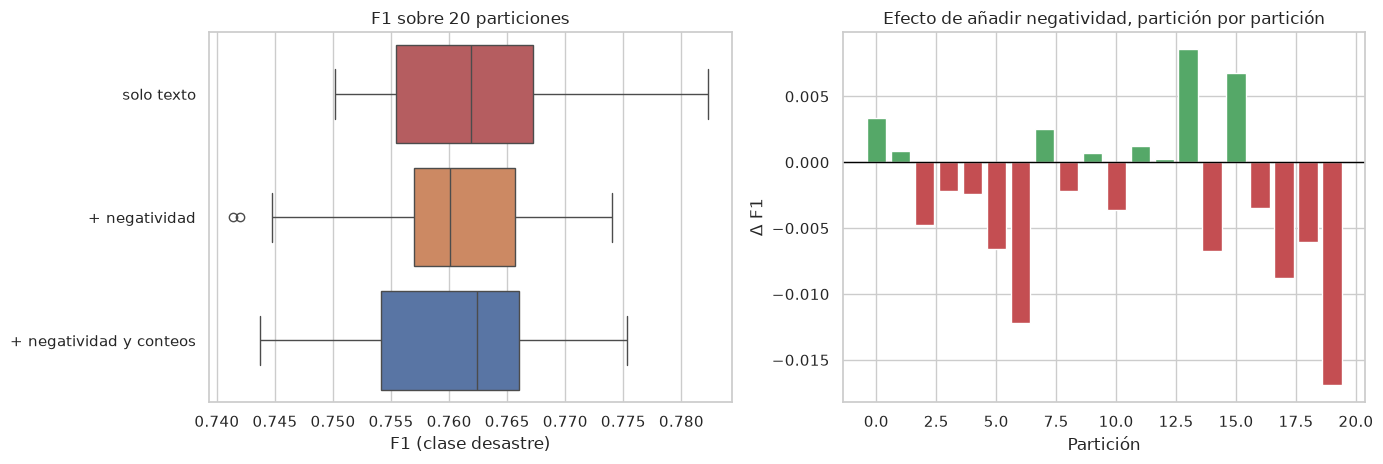

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.boxplot(data=resultados, x='f1', y='modelo', hue='modelo', legend=False,
            palette=['#C44E52', '#DD8452', '#4C72B0'], ax=axes[0])
axes[0].set_title('F1 sobre 20 particiones')
axes[0].set_xlabel('F1 (clase desastre)')
axes[0].set_ylabel('')

delta = pivot['+ negatividad'] - base
axes[1].bar(range(20), delta, color=['#55A868' if d > 0 else '#C44E52' for d in delta])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Efecto de añadir negatividad, partición por partición')
axes[1].set_xlabel('Partición')
axes[1].set_ylabel('Δ F1')

plt.tight_layout()
plt.show()

### ¿Mejoró el modelo?

**No.** Añadir la negatividad cambia el F1 en **-0.0026**, es decir que lo empeora en un
cuarto de punto porcentual. Gana en 8 de 20 particiones, menos de la mitad, y la prueba t
pareada da p = 0.075, por encima del umbral convencional de 0.05.

La lectura correcta no es "empeora" sino **"la diferencia es indistinguible de cero"**, con
una tendencia levemente negativa. Añadir también los conteos de palabras positivas y
negativas no cambia el panorama: -0.0017 con p = 0.232.

Es un resultado que va contra la intuición del inciso 9, donde la negatividad separaba las
clases con p ≈ 1e-80. La sección siguiente investiga por qué una variable con esa diferencia
tan marcada no aporta nada al clasificador.

## 4. Por qué no aporta

Hay dos explicaciones posibles y conviene distinguirlas, porque llevan a conclusiones
distintas: que la variable no tenga señal, o que tenga señal pero el modelo ya la posea por
otra vía.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

solo_neg = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
]).fit(X_train[['negatividad']], y_train)

pred_neg = solo_neg.predict(X_test[['negatividad']])
prob_neg = solo_neg.predict_proba(X_test[['negatividad']])[:, 1]

print('Modelo entrenado ÚNICAMENTE con la negatividad, sin texto:')
print(f'  F1      = {f1_score(y_test, pred_neg):.4f}')
print(f'  ROC-AUC = {roc_auc_score(y_test, prob_neg):.4f}   (0.5 sería azar)')

Modelo entrenado ÚNICAMENTE con la negatividad, sin texto:
  F1      = 0.5266
  ROC-AUC = 0.6287   (0.5 sería azar)


In [9]:
con_neg = build_model_columnas(['negatividad']).fit(X_train, y_train)
coeficientes = con_neg.named_steps['clf'].coef_[0]
n_texto = con_neg.named_steps['pre'].transformers_[0][1].get_feature_names_out().shape[0]
coef_negatividad = coeficientes[n_texto]

percentil = (np.abs(coeficientes[:n_texto]) < abs(coef_negatividad)).mean()

print(f'Coeficiente asignado a la negatividad: {coef_negatividad:+.4f}')
print(f'  supera en magnitud al {percentil:.1%} de los {n_texto:,} coeficientes de texto')
print(f'  |coeficiente| mediano del texto: {np.median(np.abs(coeficientes[:n_texto])):.4f}')

Coeficiente asignado a la negatividad: +0.3936
  supera en magnitud al 95.9% de los 52,815 coeficientes de texto
  |coeficiente| mediano del texto: 0.1368


La primera explicación queda descartada. La variable **sí tiene señal**: por sí sola alcanza
un ROC-AUC de 0.629, claramente por encima del azar, y el modelo combinado le asigna un
coeficiente que supera en magnitud al 95.9% de los términos de texto. No es una variable que
el modelo esté ignorando.

Queda la segunda: que la información ya esté en el modelo por otra vía.

In [10]:
from src.sentimiento import analizador

lexicon = analizador().lexicon
nombres = solo_texto.named_steps['pre'].transformers_[0][1].get_feature_names_out()
pesos = pd.Series(solo_texto.named_steps['clf'].coef_[0], index=nombres)

top30 = pesos.nlargest(30)
en_lexicon = [t for t in top30.index if t in lexicon]

print(f'De los 30 términos que más empujan hacia DESASTRE, {len(en_lexicon)} tienen')
print(f'carga de sentimiento en el léxico de VADER:\n')
for t in en_lexicon:
    print(f'  {t:12s} coef_modelo={top30[t]:+.3f}   valencia_VADER={lexicon[t]:+.1f}')

De los 30 términos que más empujan hacia DESASTRE, 7 tienen
carga de sentimiento en el léxico de VADER:

  fire         coef_modelo=+3.931   valencia_VADER=-1.4
  killed       coef_modelo=+2.957   valencia_VADER=-3.5
  suicide      coef_modelo=+2.810   valencia_VADER=-3.5
  accident     coef_modelo=+2.431   valencia_VADER=-2.1
  disaster     coef_modelo=+2.173   valencia_VADER=-3.1
  attack       coef_modelo=+2.139   valencia_VADER=-2.1
  severe       coef_modelo=+2.105   valencia_VADER=-1.6


Ahí está el solapamiento. Los términos que más pesan en el clasificador son en buena parte
los mismos que determinan la negatividad del tweet. `fire`, `killed`, `suicide`, `disaster`,
`attack` son a la vez los mejores predictores de desastre y las palabras que hunden el
`compound`.

La negatividad es entonces un **resumen escalar de información que el modelo ya tiene
desagregada** en 52,815 features. Comprime en un número lo que el TF-IDF maneja término por
término, y esa compresión pierde detalle sin añadir nada.

## 5. La comprobación decisiva

Si la explicación es correcta, hay una predicción que se puede falsar: **la negatividad
debería ayudar cuando el modelo dispone de poco vocabulario**, y dejar de ayudar conforme el
vocabulario crece hasta contener esa misma información.

Repetimos el entrenamiento limitando `max_features` del vectorizador a distintos tamaños,
promediando 8 particiones en cada caso.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

def armar(max_features, con_negatividad):
    tfidf = TfidfVectorizer(
        ngram_range=BEST_PARAMS['tfidf__ngram_range'],
        min_df=BEST_PARAMS['tfidf__min_df'],
        sublinear_tf=BEST_PARAMS['tfidf__sublinear_tf'],
        max_features=max_features,
    )
    transformadores = [('tfidf', tfidf, 'text')]
    if con_negatividad:
        transformadores.append(('num', StandardScaler(), ['negatividad']))
    return Pipeline([
        ('pre', ColumnTransformer(transformadores)),
        ('clf', LogisticRegression(C=BEST_PARAMS['clf__C'],
                                   class_weight=BEST_PARAMS['clf__class_weight'],
                                   max_iter=1000, random_state=RANDOM_STATE)),
    ])

filas = []
for mf in [50, 100, 250, 500, 1000, 5000, None]:
    sin_v, con_v = [], []
    for semilla in range(8):
        Xtr, Xte, ytr, yte = train_test_split(
            datos, y, test_size=TEST_SIZE, random_state=semilla, stratify=y)
        sin_v.append(f1_score(yte, armar(mf, False).fit(Xtr, ytr).predict(Xte)))
        con_v.append(f1_score(yte, armar(mf, True).fit(Xtr, ytr).predict(Xte)))
    filas.append({
        'vocabulario': 'completo (52,815)' if mf is None else f'{mf:,}',
        'orden': mf if mf is not None else 100000,
        'solo_texto': np.mean(sin_v),
        'con_negatividad': np.mean(con_v),
        'delta': np.mean(con_v) - np.mean(sin_v),
    })

barrido = pd.DataFrame(filas)
display(barrido[['vocabulario', 'solo_texto', 'con_negatividad', 'delta']].round(4))

,vocabulario,solo_texto,con_negatividad,delta
0,50,0.5410,0.5997,0.0587
1,100,0.6227,0.6442,0.0215
2,250,0.6782,0.6860,0.0078
3,500,0.7246,0.7350,0.0104
4,"1,000",0.7400,0.7406,0.0006
5,"5,000",0.7518,0.7522,0.0005
6,"completo (52,815)",0.7606,0.7579,-0.0027


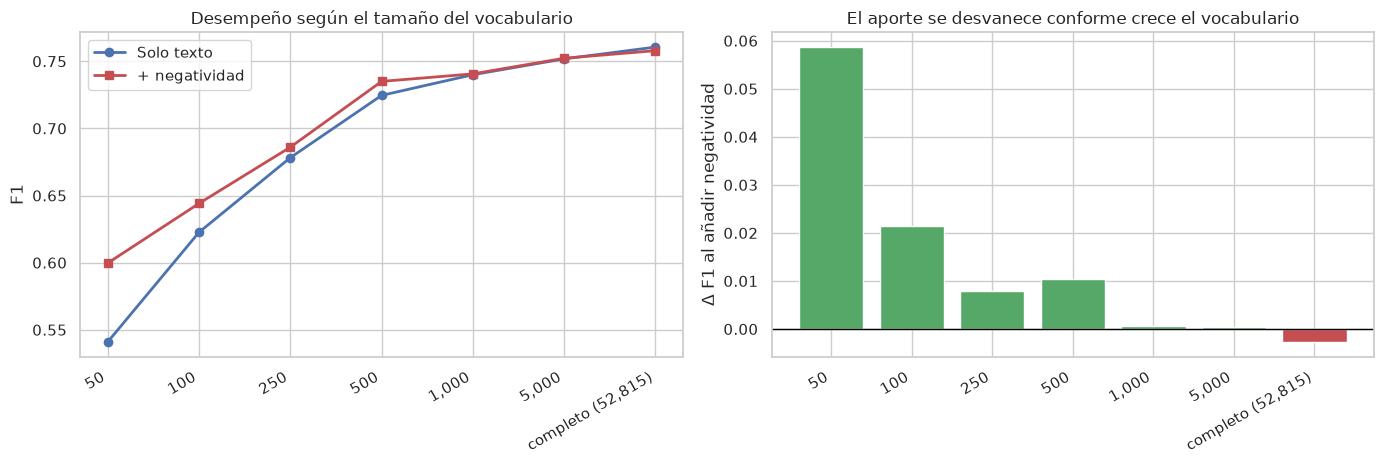

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

x = range(len(barrido))
axes[0].plot(x, barrido['solo_texto'], 'o-', color='#4C72B0', lw=2, label='Solo texto')
axes[0].plot(x, barrido['con_negatividad'], 's-', color='#C44E52', lw=2, label='+ negatividad')
axes[0].set_xticks(x)
axes[0].set_xticklabels(barrido['vocabulario'], rotation=30, ha='right')
axes[0].set_ylabel('F1')
axes[0].set_title('Desempeño según el tamaño del vocabulario')
axes[0].legend()

axes[1].bar(x, barrido['delta'],
            color=['#55A868' if d > 0 else '#C44E52' for d in barrido['delta']])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(barrido['vocabulario'], rotation=30, ha='right')
axes[1].set_ylabel('Δ F1 al añadir negatividad')
axes[1].set_title('El aporte se desvanece conforme crece el vocabulario')

plt.tight_layout()
plt.show()

La predicción se cumple con nitidez. Con 50 features la negatividad aporta **+0.059 de F1**,
una mejora sustancial. El aporte cae a +0.022 con 100 features, a +0.008 con 250, a +0.0006
con 1,000, y se vuelve negativo con el vocabulario completo.

Esto confirma que la variable **contiene información real y útil**, pero es información que
el TF-IDF ya captura por sí solo en cuanto dispone de suficientes términos. Con vocabulario
completo, añadirla solo agrega un parámetro más que estimar, y el modelo paga ese costo sin
recibir nada a cambio.

## 6. Evaluación final del modelo reentrenado

                 precision    recall  f1-score   support

No desastre (0)      0.816     0.846     0.831       869
   Desastre (1)      0.785     0.746     0.765       654

       accuracy                          0.803      1523
      macro avg      0.800     0.796     0.798      1523
   weighted avg      0.802     0.803     0.802      1523



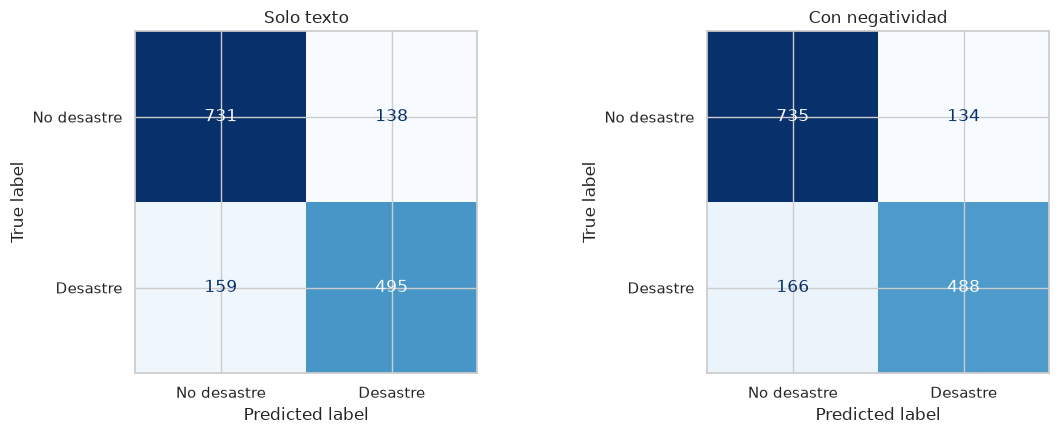

,accuracy,precision,recall,f1,roc_auc,Δ
solo texto,0.805,0.7820,0.7569,0.7692,0.8687,0.0000
con negatividad,0.803,0.7846,0.7462,0.7649,0.8669,-0.0043


In [13]:
print(report(con_neg, X_test, y_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(solo_texto, X_test, y_test, 'Solo texto', ax=axes[0])
plot_confusion(con_neg, X_test, y_test, 'Con negatividad', ax=axes[1])
plt.tight_layout()
plt.show()

comparativa = pd.DataFrame({
    'solo texto': evaluate_model(solo_texto, X_test, y_test),
    'con negatividad': evaluate_model(con_neg, X_test, y_test),
}).T
comparativa['Δ'] = comparativa['f1'] - comparativa.loc['solo texto', 'f1']
display(comparativa.round(4))

## 7. Conclusiones

**¿La inclusión de la variable mejoró los resultados del modelo?**

No. Sobre 20 particiones aleatorias el F1 pasa de 0.7622 a 0.7597, una diferencia de
**-0.0026** que no alcanza significancia estadística (p = 0.075) y que gana en apenas 8 de
20 particiones. La conclusión honesta es que la diferencia es indistinguible de cero, con
tendencia levemente negativa. Añadir además los conteos de palabras positivas y negativas
tampoco ayuda (-0.0017, p = 0.232).

**¿En qué medida, y por qué?**

El resultado sorprende frente al inciso 9, donde la negatividad separaba las clases con
p ≈ 1e-80. La investigación de las secciones 4 y 5 explica la aparente contradicción:

- La variable **no carece de señal**: entrenada sola alcanza ROC-AUC de 0.629, y el modelo
  combinado le asigna un coeficiente mayor en magnitud que al 95.9% de los términos de texto.
- Pero **la señal es redundante**. De los 30 términos que más empujan hacia desastre, 7
  tienen carga de sentimiento en el léxico de VADER: `fire`, `killed`, `suicide`, `accident`,
  `disaster`, `attack`, `severe`. Las palabras que hacen negativo a un tweet son en buena
  medida las mismas que lo hacen predecible como desastre.
- El barrido de vocabulario lo confirma de forma directa: con 50 features la negatividad
  aporta +0.059 de F1, y ese aporte decae hasta desaparecer conforme el vocabulario crece.

La variable comprime en un escalar lo que el TF-IDF ya representa desagregado en 52,815
términos. Es un resumen fiel pero prescindible cuando se dispone del detalle.

**Qué modelo conviene entregar.** El de solo texto del inciso 6. Es igual de bueno, más
simple, y no arrastra la dependencia de NLTK y del léxico de VADER en tiempo de predicción.
La variable de negatividad conserva valor descriptivo, como mostró el inciso 9, pero no
predictivo sobre este modelo.